# OULAF Graph Schema and Neural Network Model

## PROJECT STRUCTURE (Reproducible)

project_root/
│
├── data/
│   ├── studentInfo.csv
│   ├── studentVle.csv
│   ├── studentAssessment.csv
│   ├── assessments.csv
│   ├── vle.csv
│   └── courses.csv
│
├── output/
│   ├── results/
│   ├── plots/
│   ├── graphs/
│   └── logs/
│
├── src/
│   └── graph_pipeline.py   reusable functions
│
└── oulad_graph_pipeline.ipynb


In [1]:
%pip install networkx
%pip install torch
%pip install ipywidgets
%pip install torch-geometric
%pip install matplotlib
%pip install pandas
%pip install numpy
%pip install tqdm
%pip install scikit-learn
%pip install seaborn
%pip install jupyterlab


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note

## 1. Setup and paths

In [2]:
import os
import pandas as pd
import numpy as np

BASE_PATH = "./"
DATA_PATH = os.path.join(BASE_PATH, "../data/raw")
OUT_PATH = os.path.join(BASE_PATH, "output")

os.makedirs(OUT_PATH, exist_ok=True)

FILES = {
    "studentInfo": "studentInfo.csv",
    "studentAssessment": "studentAssessment.csv",
    "studentVle": "studentVle.csv",
    "assessments": "assessments.csv",
    "vle": "vle.csv",
    "courses": "courses.csv"
}


## 2. Load and verify data

In [3]:

def load_data():
    data = {}
    for k, f in FILES.items():
        path = os.path.join(DATA_PATH, f)
        assert os.path.exists(path), f"Missing {path}"
        data[k] = pd.read_csv(path)
        print(f"{k}: {data[k].shape}")
    return data

data = load_data()
display(data["studentInfo"].head())
display(data["studentAssessment"].head())
display(data["studentVle"].head())
display(data["assessments"].head())
display(data["vle"].head())
display(data["courses"].head())


studentInfo: (32593, 12)
studentAssessment: (173912, 5)
studentVle: (10655280, 6)
assessments: (206, 6)
vle: (6364, 6)
courses: (22, 3)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0
3,AAA,2013J,1755,TMA,166.0,20.0
4,AAA,2013J,1756,TMA,215.0,30.0


,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN


,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240


## 3. Define taks and target

In [4]:

def create_enrollment(data):
    df = data["studentInfo"].copy()
    
    df["enrollment_id"] = (
        df["id_student"].astype(str) + "_" +
        df["code_module"] + "_" +
        df["code_presentation"]
    )
    
    # Risk definition
    df["risk"] = df["final_result"].map({
        "Fail": 1,
        "Withdrawn": 1,
        "Pass": 0,
        "Distinction": 0
    })
    
    return df

enrollment = create_enrollment(data)

display(enrollment.head())


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,enrollment_id,risk
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,11391_AAA_2013J,0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,28400_AAA_2013J,0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,30268_AAA_2013J,1
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,31604_AAA_2013J,0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,32885_AAA_2013J,0


## 4. Prediction windows

In [5]:

WEEKS = [2,4,6,8]

def cutoff(df, date_col, week):
    return df[df[date_col] <= week*7]


## 5. Feature groups

In [6]:

FEATURE_GROUPS = {
    "demographics": ["age_band","gender","highest_education"],
    "vle": ["total_clicks","interaction_freq"],
    "assessment": ["avg_score","num_submissions"],
    "combined": "ALL"
}

display(FEATURE_GROUPS)



{'demographics': ['age_band', 'gender', 'highest_education'],
 'vle': ['total_clicks', 'interaction_freq'],
 'assessment': ['avg_score', 'num_submissions'],
 'combined': 'ALL'}

## 6. Build aggregated features

In [7]:

def build_features(data, enrollment, week):

    vle = cutoff(data["studentVle"], "date", week)
    assess = cutoff(data["studentAssessment"], "date_submitted", week)

    # --- Aggregations ---
    vle_agg = vle.groupby("id_student").agg(
        total_clicks=("sum_click", "sum"),
        interaction_freq=("date", "count")
    ).reset_index()

    assess_agg = assess.groupby("id_student").agg(
        avg_score=("score", "mean"),
        num_submissions=("id_assessment", "count")
    ).reset_index()

    # --- Ensure consistent dtype for merging ---
    for d in [enrollment, vle_agg, assess_agg]:
        d["id_student"] = pd.to_numeric(d["id_student"], errors="coerce")

    # --- Merge ---
    df = enrollment.merge(vle_agg, on="id_student", how="left")
    df = df.merge(assess_agg, on="id_student", how="left")

    # --- Numeric features ---
    num_cols = ["total_clicks", "interaction_freq", "avg_score", "num_submissions"]
    df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

    # --- String columns ---
    str_cols = df.select_dtypes(include=["object", "string"]).columns
    df[str_cols] = df[str_cols].fillna("")

    return df

#print(f"Building features for week {WEEKS[0]}...")
#features_week_2 = build_features(data, enrollment, WEEKS[0])
#features_week_2.head()




## 7. Graph construction

In [8]:
#Verify is data is actually loading correctly

print("\n=== DATA CHECK ===")
for k, v in data.items():
    print(f"{k}: shape={v.shape}")



=== DATA CHECK ===
studentInfo: shape=(32593, 12)
studentAssessment: shape=(173912, 5)
studentVle: shape=(10655280, 6)
assessments: shape=(206, 6)
vle: shape=(6364, 6)
courses: shape=(22, 3)


In [9]:
#Verify cutoff is not returning empty dataframes
for k, v in data.items():
    for week in WEEKS:
        if k == "studentInfo":
            df_cutoff = v.copy()
        elif k == "studentVle":
            df_cutoff = cutoff(v, "date", week)
        elif k == "studentAssessment":
            df_cutoff = cutoff(v, "date_submitted", week)
        else:
            continue

        print(f"Cutoff check for {k} at week {week}: shape={df_cutoff.shape}")

        
print("\n=== AFTER CUTOFF ===")
studentVle = cutoff(data["studentVle"], "date", WEEKS[0])
studentAssessment = cutoff(data["studentAssessment"], "date_submitted", WEEKS[0])

#print("studentVle:", studentVle.shape)
#print("studentAssessment:", studentAssessment.shape)


Cutoff check for studentInfo at week 2: shape=(32593, 12)
Cutoff check for studentInfo at week 4: shape=(32593, 12)
Cutoff check for studentInfo at week 6: shape=(32593, 12)
Cutoff check for studentInfo at week 8: shape=(32593, 12)
Cutoff check for studentAssessment at week 2: shape=(5587, 5)
Cutoff check for studentAssessment at week 4: shape=(25614, 5)
Cutoff check for studentAssessment at week 6: shape=(33927, 5)
Cutoff check for studentAssessment at week 8: shape=(51578, 5)
Cutoff check for studentVle at week 2: shape=(1819777, 6)
Cutoff check for studentVle at week 4: shape=(2847851, 6)
Cutoff check for studentVle at week 6: shape=(3603046, 6)
Cutoff check for studentVle at week 8: shape=(4331544, 6)

=== AFTER CUTOFF ===


In [10]:

def build_graph(data, week):
    print(f"build_graph is running for week={week}")


from torch_geometric.data import HeteroData
import torch

def build_graph(data, week):
    
    start = time.time()
    
    student_info = data["studentInfo"]
    assessments = data["assessments"]
    vle_df = data["vle"]
    
    student_vle = cutoff(data["studentVle"], "date", week)
    student_assess = cutoff(data["studentAssessment"], "date_submitted", week)
    
    # Aggregate VLE interactions 
    vle_agg = student_vle.groupby(["id_student","id_site"]).agg(
        clicks=("sum_click","sum"),
        freq=("date","count")
    ).reset_index()
    
    # Create graph
    g = HeteroData()
    
    # Node types 
    g["student"].num_nodes = student_info["id_student"].nunique()
    g["course"].num_nodes = student_info[["code_module","code_presentation"]].drop_duplicates().shape[0]
    g["assessment"].num_nodes = assessments.shape[0]
    g["vle"].num_nodes = vle_df.shape[0]
    g["enrollment"].num_nodes = enrollment.shape[0]
    
    # Edges 
    # Student → Course
    g["student","enrolled","course"].edge_index = torch.tensor([
        student_info["id_student"].values,
        pd.factorize(student_info["code_module"] + "_" + student_info["code_presentation"])[0]
    ])
    
    # Student → VLE
    g["student","interacts","vle"].edge_index = torch.tensor([
        vle_agg["id_student"].values,
        vle_agg["id_site"].values
    ])
    
    g["student","interacts","vle"].edge_attr = torch.tensor(
        vle_agg[["clicks","freq"]].values, dtype=torch.float
    )
    
    # Student → Assessment
    g["student","submitted","assessment"].edge_index = torch.tensor([
        student_assess["id_student"].values,
        student_assess["id_assessment"].values
    ])
    
    return g


Schema summary

In [11]:

def display_graph_schema(g):
    print("\n=== NODE TYPES ===")
    for node_type in g.node_types:
        print(f"{node_type}: {g[node_type].num_nodes}")

    print("\n=== EDGE TYPES ===")
    for edge_type in g.edge_types:
        edge_index = g[edge_type].edge_index
        print(f"{edge_type}: {edge_index.shape[1]} edges")

    print("\n=== DETAILED SCHEMA ===")
    for edge_type in g.edge_types:
        src, rel, dst = edge_type
        print(f"{src} -[{rel}]-> {dst}")


Edge samples

In [12]:

def display_edge_samples(g, n=5):
    print("\n=== EDGE SAMPLES ===")
    
    for edge_type in g.edge_types:
        edge_index = g[edge_type].edge_index
        
        print(f"\n{edge_type}:")
        
        src_nodes = edge_index[0][:n].tolist()
        dst_nodes = edge_index[1][:n].tolist()
        
        for s, d in zip(src_nodes, dst_nodes):
            print(f"{s} -> {d}")


Schema diagram

In [13]:

import networkx as nx
import matplotlib.pyplot as plt

def plot_schema(g):
    G = nx.DiGraph()

    for edge_type in g.edge_types:
        src, rel, dst = edge_type
        G.add_edge(src, dst, label=rel)

    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(6,5))
    nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=2000)

    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    plt.title("Heterogeneous Graph Schema")
    plt.show()



=== NODE TYPES ===
student: 28785
course: 22
assessment: 206
vle: 6364

=== EDGE TYPES ===
('student', 'enrolled', 'course'): 32593 edges
('student', 'interacts', 'vle'): 634723 edges
('student', 'submitted', 'assessment'): 5587 edges

=== DETAILED SCHEMA ===
student -[enrolled]-> course
student -[interacts]-> vle
student -[submitted]-> assessment

=== EDGE SAMPLES ===

('student', 'enrolled', 'course'):
11391 -> 0
28400 -> 0
30268 -> 0
31604 -> 0
32885 -> 0

('student', 'interacts', 'vle'):
6516 -> 877012
6516 -> 877023
6516 -> 877025
6516 -> 877030
6516 -> 877040

('student', 'submitted', 'assessment'):
53025 -> 1752
111717 -> 1752
306466 -> 1752
342514 -> 1752
342972 -> 1752


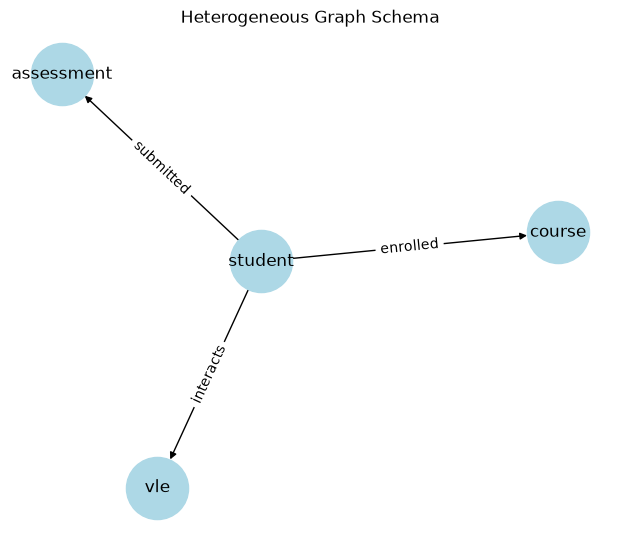


=== NODE TYPES ===
student: 28785
course: 22
assessment: 206
vle: 6364

=== EDGE TYPES ===
('student', 'enrolled', 'course'): 32593 edges
('student', 'interacts', 'vle'): 835935 edges
('student', 'submitted', 'assessment'): 25614 edges

=== DETAILED SCHEMA ===
student -[enrolled]-> course
student -[interacts]-> vle
student -[submitted]-> assessment

=== EDGE SAMPLES ===

('student', 'enrolled', 'course'):
11391 -> 0
28400 -> 0
30268 -> 0
31604 -> 0
32885 -> 0

('student', 'interacts', 'vle'):
6516 -> 877012
6516 -> 877023
6516 -> 877025
6516 -> 877030
6516 -> 877034

('student', 'submitted', 'assessment'):
11391 -> 1752
28400 -> 1752
31604 -> 1752
32885 -> 1752
38053 -> 1752


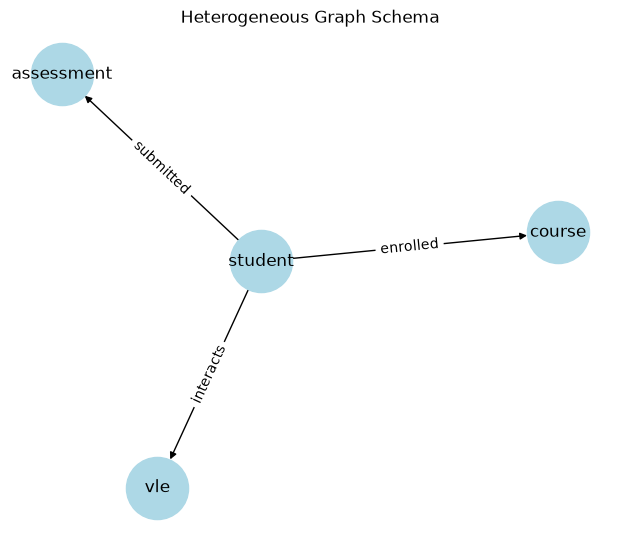


=== NODE TYPES ===
student: 28785
course: 22
assessment: 206
vle: 6364

=== EDGE TYPES ===
('student', 'enrolled', 'course'): 32593 edges
('student', 'interacts', 'vle'): 952241 edges
('student', 'submitted', 'assessment'): 33927 edges

=== DETAILED SCHEMA ===
student -[enrolled]-> course
student -[interacts]-> vle
student -[submitted]-> assessment

=== EDGE SAMPLES ===

('student', 'enrolled', 'course'):
11391 -> 0
28400 -> 0
30268 -> 0
31604 -> 0
32885 -> 0

('student', 'interacts', 'vle'):
6516 -> 877012
6516 -> 877023
6516 -> 877025
6516 -> 877030
6516 -> 877034

('student', 'submitted', 'assessment'):
11391 -> 1752
28400 -> 1752
31604 -> 1752
32885 -> 1752
38053 -> 1752


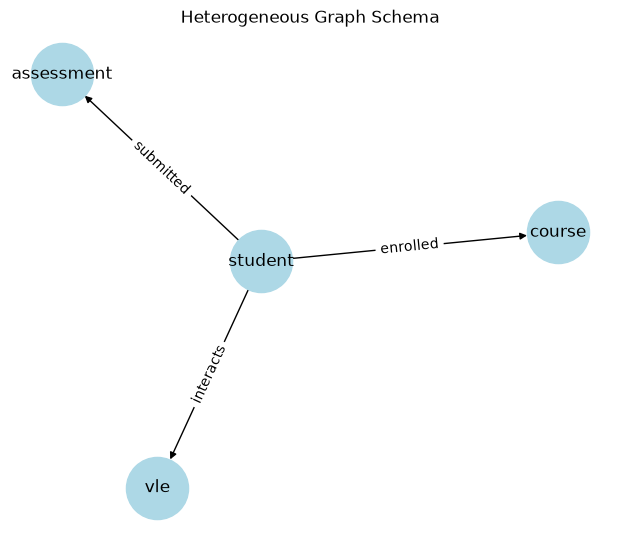


=== NODE TYPES ===
student: 28785
course: 22
assessment: 206
vle: 6364

=== EDGE TYPES ===
('student', 'enrolled', 'course'): 32593 edges
('student', 'interacts', 'vle'): 1056217 edges
('student', 'submitted', 'assessment'): 51578 edges

=== DETAILED SCHEMA ===
student -[enrolled]-> course
student -[interacts]-> vle
student -[submitted]-> assessment

=== EDGE SAMPLES ===

('student', 'enrolled', 'course'):
11391 -> 0
28400 -> 0
30268 -> 0
31604 -> 0
32885 -> 0

('student', 'interacts', 'vle'):
6516 -> 877012
6516 -> 877015
6516 -> 877023
6516 -> 877025
6516 -> 877030

('student', 'submitted', 'assessment'):
11391 -> 1752
28400 -> 1752
31604 -> 1752
32885 -> 1752
38053 -> 1752


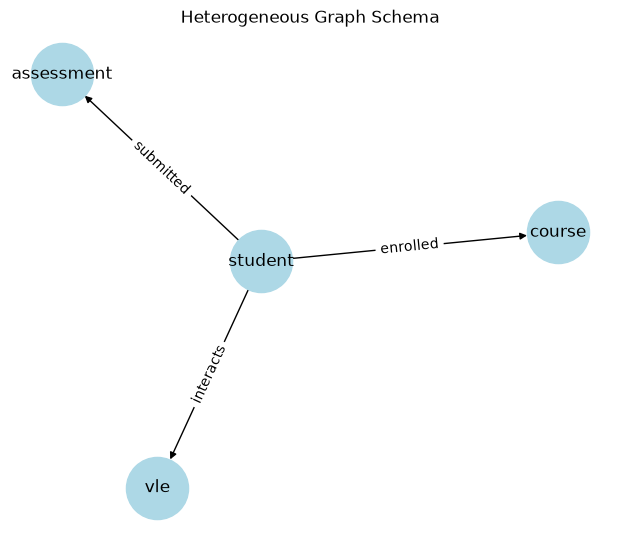


=== EDGE CHECK ===
enrolled edges: 32593
vle edges: 634723
assessment edges: 5587


In [37]:
import time

# Verify edge onstruction and graph schema for week 2
g_week_2 = build_graph(data, WEEKS[0])

# Verify edge construction and graph schema for week 4
g_week_4 = build_graph(data, WEEKS[1])

# Verify edge construction and graph schema for week 6
g_week_6 = build_graph(data, WEEKS[2])

# Verify edge construction and graph schema for week 8
g_week_8 = build_graph(data, WEEKS[3])


print("\n=== EDGE CHECK ===")

studentInfo = data["studentInfo"]

vleAgg = studentVle.groupby(["id_student", "id_site"]).agg(
    clicks=("sum_click", "sum"),
    freq=("date", "count")
).reset_index()

studentAssess = studentAssessment

print("enrolled edges:", len(studentInfo))
print("vle edges:", len(vleAgg))
print("assessment edges:", len(studentAssess))


Modify the function


=== GRAPH CHECK ===

=== NODE TYPES ===
student: 28785
course: 22
assessment: 206
vle: 6364

=== EDGE TYPES ===
('student', 'enrolled', 'course'): 32593 edges
('student', 'interacts', 'vle'): 634723 edges
('student', 'submitted', 'assessment'): 5587 edges

=== DETAILED SCHEMA ===
student -[enrolled]-> course
student -[interacts]-> vle
student -[submitted]-> assessment

=== EDGE SAMPLES ===

('student', 'enrolled', 'course'):
11391 -> 0
28400 -> 0
30268 -> 0
31604 -> 0
32885 -> 0

('student', 'interacts', 'vle'):
6516 -> 877012
6516 -> 877023
6516 -> 877025
6516 -> 877030
6516 -> 877040

('student', 'submitted', 'assessment'):
53025 -> 1752
111717 -> 1752
306466 -> 1752
342514 -> 1752
342972 -> 1752


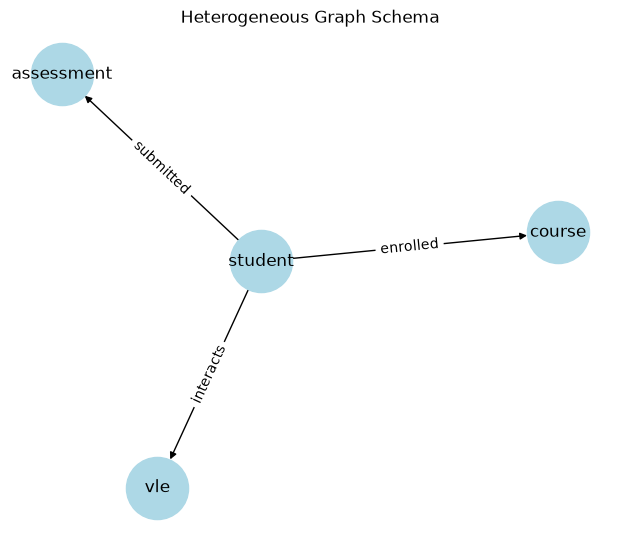


=== NODE TYPES ===
student: 28785
course: 22
assessment: 206
vle: 6364

=== EDGE TYPES ===
('student', 'enrolled', 'course'): 32593 edges
('student', 'interacts', 'vle'): 835935 edges
('student', 'submitted', 'assessment'): 25614 edges

=== DETAILED SCHEMA ===
student -[enrolled]-> course
student -[interacts]-> vle
student -[submitted]-> assessment

=== EDGE SAMPLES ===

('student', 'enrolled', 'course'):
11391 -> 0
28400 -> 0
30268 -> 0
31604 -> 0
32885 -> 0

('student', 'interacts', 'vle'):
6516 -> 877012
6516 -> 877023
6516 -> 877025
6516 -> 877030
6516 -> 877034

('student', 'submitted', 'assessment'):
11391 -> 1752
28400 -> 1752
31604 -> 1752
32885 -> 1752
38053 -> 1752


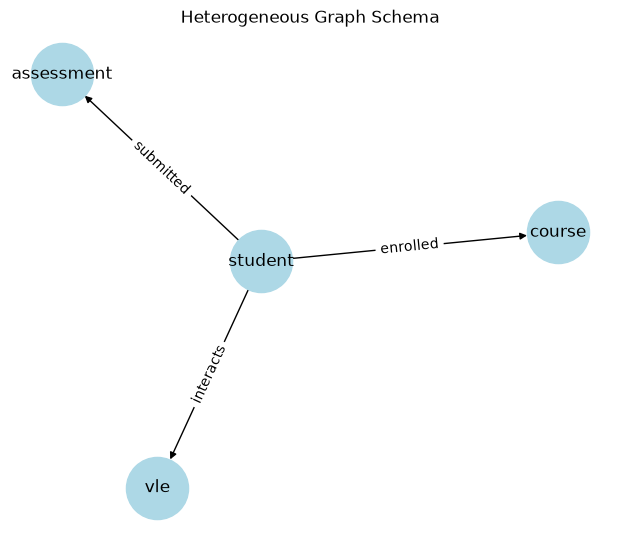


=== NODE TYPES ===
student: 28785
course: 22
assessment: 206
vle: 6364

=== EDGE TYPES ===
('student', 'enrolled', 'course'): 32593 edges
('student', 'interacts', 'vle'): 952241 edges
('student', 'submitted', 'assessment'): 33927 edges

=== DETAILED SCHEMA ===
student -[enrolled]-> course
student -[interacts]-> vle
student -[submitted]-> assessment

=== EDGE SAMPLES ===

('student', 'enrolled', 'course'):
11391 -> 0
28400 -> 0
30268 -> 0
31604 -> 0
32885 -> 0

('student', 'interacts', 'vle'):
6516 -> 877012
6516 -> 877023
6516 -> 877025
6516 -> 877030
6516 -> 877034

('student', 'submitted', 'assessment'):
11391 -> 1752
28400 -> 1752
31604 -> 1752
32885 -> 1752
38053 -> 1752


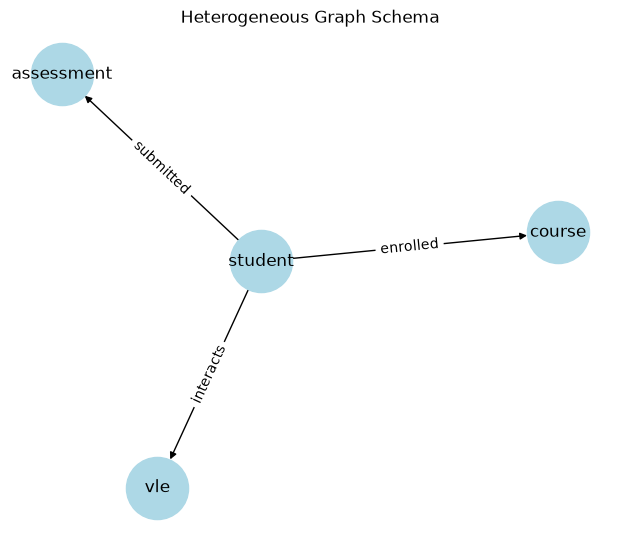


=== NODE TYPES ===
student: 28785
course: 22
assessment: 206
vle: 6364

=== EDGE TYPES ===
('student', 'enrolled', 'course'): 32593 edges
('student', 'interacts', 'vle'): 1056217 edges
('student', 'submitted', 'assessment'): 51578 edges

=== DETAILED SCHEMA ===
student -[enrolled]-> course
student -[interacts]-> vle
student -[submitted]-> assessment

=== EDGE SAMPLES ===

('student', 'enrolled', 'course'):
11391 -> 0
28400 -> 0
30268 -> 0
31604 -> 0
32885 -> 0

('student', 'interacts', 'vle'):
6516 -> 877012
6516 -> 877015
6516 -> 877023
6516 -> 877025
6516 -> 877030

('student', 'submitted', 'assessment'):
11391 -> 1752
28400 -> 1752
31604 -> 1752
32885 -> 1752
38053 -> 1752


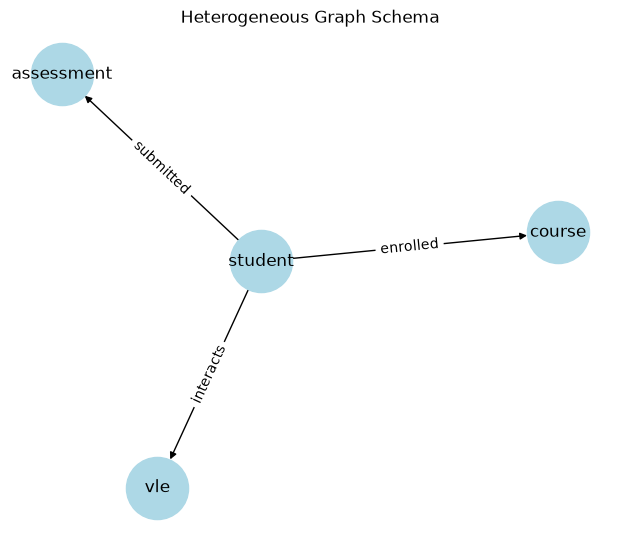

In [38]:

def build_graph(data, week):
    
    start = time.time()
    
    student_info = data["studentInfo"]
    assessments = data["assessments"]
    vle_df = data["vle"]
    
    student_vle = cutoff(data["studentVle"], "date", week)
    student_assess = cutoff(data["studentAssessment"], "date_submitted", week)
    
    # --- Aggregate VLE ---
    vle_agg = student_vle.groupby(["id_student","id_site"]).agg(
        clicks=("sum_click","sum"),
        freq=("date","count")
    ).reset_index()
    
    g = HeteroData()
    
    # --- Nodes ---
    g["student"].num_nodes = student_info["id_student"].nunique()
    g["course"].num_nodes = student_info[["code_module","code_presentation"]].drop_duplicates().shape[0]
    g["assessment"].num_nodes = assessments.shape[0]
    g["vle"].num_nodes = vle_df.shape[0]
    
    # --- Edges ---
    g["student","enrolled","course"].edge_index = torch.tensor([
        student_info["id_student"].values,
        pd.factorize(student_info["code_module"] + "_" + student_info["code_presentation"])[0]
    ], dtype=torch.long)

    g["student","interacts","vle"].edge_index = torch.tensor([
        vle_agg["id_student"].values,
        vle_agg["id_site"].values
    ], dtype=torch.long)

    g["student","interacts","vle"].edge_attr = torch.tensor(
        vle_agg[["clicks","freq"]].values, dtype=torch.float
    )

    g["student","submitted","assessment"].edge_index = torch.tensor([
        student_assess["id_student"].values,
        student_assess["id_assessment"].values
    ], dtype=torch.long)

    #  --- ADD THIS ---
    display_graph_schema(g)
    display_edge_samples(g, n=5)
    plot_schema(g)

    return g

print("\n=== GRAPH CHECK ===")
g_week_2 = build_graph(data, WEEKS[0]) 
g_week_4 = build_graph(data, WEEKS[1])
g_week_6 = build_graph(data, WEEKS[2])
g_week_8 = build_graph(data, WEEKS[3])

## 8. Graph validation


=== NODE TYPES ===
student: 28785
course: 22
assessment: 206
vle: 6364

=== EDGE TYPES ===
('student', 'enrolled', 'course'): 32593 edges
('student', 'interacts', 'vle'): 835935 edges
('student', 'submitted', 'assessment'): 25614 edges

=== DETAILED SCHEMA ===
student -[enrolled]-> course
student -[interacts]-> vle
student -[submitted]-> assessment

=== EDGE SAMPLES ===

('student', 'enrolled', 'course'):
11391 -> 0
28400 -> 0
30268 -> 0
31604 -> 0
32885 -> 0

('student', 'interacts', 'vle'):
6516 -> 877012
6516 -> 877023
6516 -> 877025
6516 -> 877030
6516 -> 877034

('student', 'submitted', 'assessment'):
11391 -> 1752
28400 -> 1752
31604 -> 1752
32885 -> 1752
38053 -> 1752


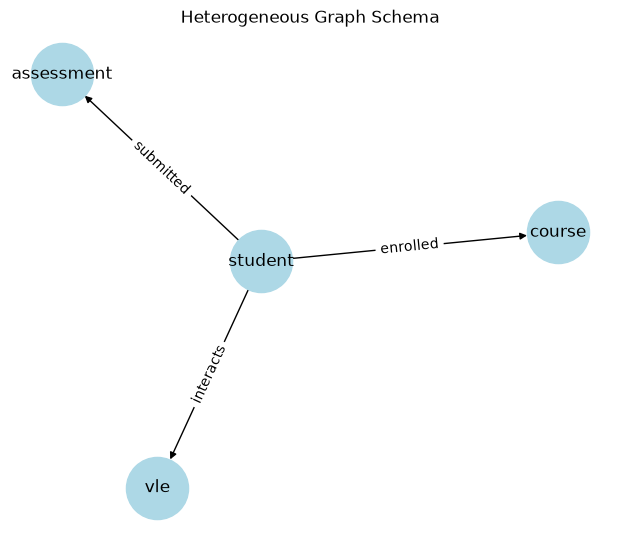

NameError: name 'validate_graph' is not defined

In [61]:


g = build_graph(data, 4)
validate_graph(g)


def validate_graph(g):
    print("Node counts:")
    for n in g.node_types:
        print(n, g[n].num_nodes)
    
    print("\nEdge counts:")
    for e in g.edge_types:
        print(e, g[e].edge_index.shape[1])


def validate_graph(g):
    
    print("DEBUG: validate_graph is running ")

    print("Node types:", g.node_types)
    print("Edge types:", g.edge_types)

    print("\nNode counts:")
    if len(g.node_types) == 0:
        print("No node types found")
    for n in g.node_types:
        print(n, g[n].num_nodes)
    
    print("\nEdge counts:")
    if len(g.edge_types) == 0:
        print("No edge types found")
    for e in g.edge_types:
        print(e, g[e].edge_index.shape[1])


## 9. Graph visualization

In [40]:

import networkx as nx
import matplotlib.pyplot as plt

visualize_student_vle(g)

def visualize_student_vle(g, sample=200):
    
    edges = g["student","interacts","vle"].edge_index.numpy()
    
    G = nx.Graph()
    for i in range(min(sample, edges.shape[1])):
        G.add_edge(f"s{edges[0,i]}", f"v{edges[1,i]}")
    
    nx.draw(G, node_size=30, alpha=0.6)
    plt.title("Student-VLE Interaction Graph")
    plt.show()


NameError: name 'visualize_student_vle' is not defined


=== NODE TYPES ===
student: 28785
course: 22
assessment: 206
vle: 6364

=== EDGE TYPES ===
('student', 'enrolled', 'course'): 32593 edges
('student', 'interacts', 'vle'): 835935 edges
('student', 'submitted', 'assessment'): 25614 edges

=== DETAILED SCHEMA ===
student -[enrolled]-> course
student -[interacts]-> vle
student -[submitted]-> assessment

=== EDGE SAMPLES ===

('student', 'enrolled', 'course'):
11391 -> 0
28400 -> 0
30268 -> 0
31604 -> 0
32885 -> 0

('student', 'interacts', 'vle'):
6516 -> 877012
6516 -> 877023
6516 -> 877025
6516 -> 877030
6516 -> 877034

('student', 'submitted', 'assessment'):
11391 -> 1752
28400 -> 1752
31604 -> 1752
32885 -> 1752
38053 -> 1752


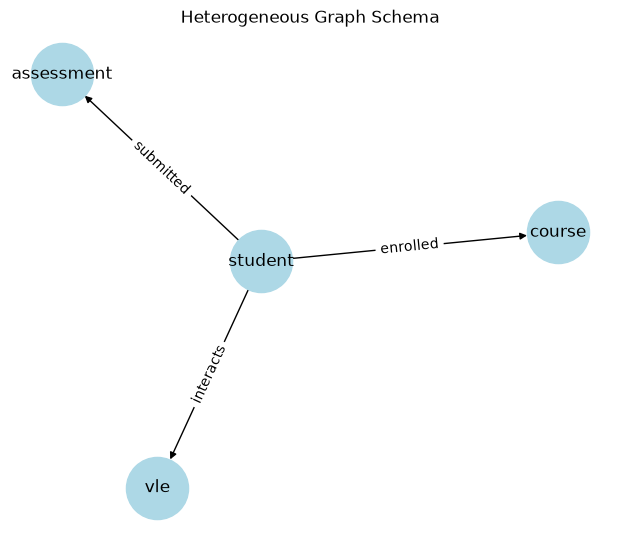

NameError: name 'visualize_graphs' is not defined

In [41]:

import networkx as nx
import matplotlib.pyplot as plt

g = build_graph(data, 4)

visualize_graphs(g, sample=200)


def visualize_graphs(g, sample=200):

    print("visualize_graphs running")

    def extract_edges(edge_type, label_prefix_src, label_prefix_dst):
        
        if edge_type not in g.edge_types:
            print(f"No {edge_type} edges in graph")
            return None
        
        edges = g[edge_type].edge_index

        print(f"{edge_type} edge count:", edges.shape[1])

        if edges.shape[1] == 0:
            print(f" {edge_type} is empty")
            return None

        edges = edges.cpu().numpy()

        G = nx.Graph()

        for i in range(min(sample, edges.shape[1])):
            G.add_edge(
                f"{label_prefix_src}{edges[0,i]}",
                f"{label_prefix_dst}{edges[1,i]}"
            )

        print(f"{edge_type} → nodes:", G.number_of_nodes())
        print(f"{edge_type} → edges:", G.number_of_edges())

        return G

    def draw_graph(G, title):
        if G is None or G.number_of_nodes() == 0:
            print(f" {title} graph is empty, skipping plot")
            return
        
        plt.figure(figsize=(6,6))
        nx.draw(G, node_size=30, alpha=0.6)
        plt.title(title)
        plt.show()

    print("Edge types:", g.edge_types)

    # =========================
    # 1. Student → VLE (existing)
    # =========================
    G_vle = extract_edges(("student","interacts","vle"), "s", "v")
    draw_graph(G_vle, "Student-VLE Interaction Graph")

    # =========================
    # 2. Student → Course
    # =========================
    G_course = extract_edges(("student","enrolled","course"), "s", "c")
    draw_graph(G_course, "Student-Course Graph")

    # =========================
    # 3. Student → Assessment
    # =========================
    G_assess = extract_edges(("student","submitted","assessment"), "s", "a")
    draw_graph(G_assess, "Student-Assessment Graph")

    # =========================
    # 4. Combined Graph
    # =========================
    print("\n Building combined graph")

    G_all = nx.Graph()

    for G_part in [G_vle, G_course, G_assess]:
        if G_part is not None:
            G_all.add_edges_from(G_part.edges())

    print("Combined nodes:", G_all.number_of_nodes())
    print("Combined edges:", G_all.number_of_edges())

    draw_graph(G_all, "Combined Heterogeneous Graph")


## 10. Splits

In [42]:
#Split the dataset into training and testing sets based on code_module and code_presentation, no random splitting of students, to avoid data leakage. The split is done at the course level, ensuring that all students from a particular course are either in the training set or the testing set.
def lcpo_split(df):
    courses = df["code_module"] + "_" + df["code_presentation"]
    test_courses = courses.sample(frac=0.2)
    
    return ~courses.isin(test_courses), courses.isin(test_courses)

print("Training set size:", lcpo_split(enrollment)[0].sum())
print("Testing set size:", lcpo_split(enrollment)[1].sum())
print("Total size:", enrollment.shape[0])
print("Training set courses:", (enrollment["code_module"] + "_" + enrollment["code_presentation"])[lcpo_split(enrollment)[0]].nunique())
print("Testing set courses:", (enrollment["code_module"] + "_" + enrollment["code_presentation"])[lcpo_split(enrollment)[1]].nunique()) 
print("Total courses:", (enrollment["code_module"] + "_" + enrollment["code_presentation"]).nunique())  
print("Training set students:", enrollment["id_student"][lcpo_split(enrollment)[0]].nunique())
print("Testing set students:", enrollment["id_student"][lcpo_split(enrollment)[1]].nunique())
print("Total students:", enrollment["id_student"].nunique())
print("Training set risk distribution:\n", enrollment["risk"][lcpo_split(enrollment)[0]].value_counts(normalize=True))  
print("Testing set risk distribution:\n", enrollment["risk"][lcpo_split(enrollment)[1]].value_counts(normalize=True))   
print("Total risk distribution:\n", enrollment["risk"].value_counts(normalize=True))
print("Training set age_band distribution:\n", enrollment["age_band"][lcpo_split(enrollment)[0]].value_counts(normalize=True))  
print("Testing set age_band distribution:\n", enrollment["age_band"][lcpo_split(enrollment)[1]].value_counts(normalize=True))   
print("Total age_band distribution:\n", enrollment["age_band"].value_counts(normalize=True))  


Training set size: 0
Testing set size: 32593
Total size: 32593
Training set courses: 0
Testing set courses: 22
Total courses: 22
Training set students: 0
Testing set students: 28785
Total students: 28785
Training set risk distribution:
 Series([], Name: proportion, dtype: float64)
Testing set risk distribution:
 risk
1    0.527966
0    0.472034
Name: proportion, dtype: float64
Total risk distribution:
 risk
1    0.527966
0    0.472034
Name: proportion, dtype: float64
Training set age_band distribution:
 Series([], Name: proportion, dtype: float64)
Testing set age_band distribution:
 age_band
0-35     0.703955
35-55    0.289418
55<=     0.006627
Name: proportion, dtype: float64
Total age_band distribution:
 age_band
0-35     0.703955
35-55    0.289418
55<=     0.006627
Name: proportion, dtype: float64


## 11. GNN Baseline (GraphSAGE)

In [43]:


from torch_geometric.nn import SAGEConv

class GNN(torch.nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.conv1 = SAGEConv((-1, -1), hidden)
        self.conv2 = SAGEConv((-1, -1), hidden)
        self.lin = torch.nn.Linear(hidden, 1)

    def forward(self, x_dict, edge_index_dict):

        # First layer
        x_dict = {
            key: self.conv1(x, edge_index_dict[list(edge_index_dict.keys())[0]])
            for key, x in x_dict.items()
        }

        # Activation
        x_dict = {k: x.relu() for k, x in x_dict.items()}

        # Second layer
        x_dict = {
            key: self.conv2(x, edge_index_dict[list(edge_index_dict.keys())[0]])
            for key, x in x_dict.items()
        }

        # Output for enrollment nodes
        return self.lin(x_dict["enrollment"])

# Model structure and parameters can be adjusted based on the specific requirements of the task, such as the number of layers, hidden dimensions, and activation functions. The current implementation uses two SAGEConv layers followed by a linear layer to produce a single output for each enrollment node.
model = GNN()
print(model)

# Parameter summary + lazy init for SAGEConv before numel()
if any(isinstance(p, torch.nn.parameter.UninitializedParameter) for p in model.parameters()):
    with torch.no_grad():
        dummy_edge = torch.tensor([[0, 1], [1, 2]], dtype=torch.long)
        dummy_x1 = torch.zeros((3, 16), dtype=torch.float)          # init conv1 in_channels
        dummy_h1 = model.conv1(dummy_x1, dummy_edge)                # shape: [3, hidden]
        _ = model.conv2(dummy_h1, dummy_edge)                       # init conv2 in_channels (hidden)

print("Parameter summary:")
for name, param in model.named_parameters():
    print(f"{name}: {param.numel()} params")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}") 



GNN(
  (conv1): SAGEConv((-1, -1), 64, aggr=mean)
  (conv2): SAGEConv((-1, -1), 64, aggr=mean)
  (lin): Linear(in_features=64, out_features=1, bias=True)
)
Parameter summary:
conv1.lin_l.weight: 1024 params
conv1.lin_l.bias: 64 params
conv1.lin_r.weight: 1024 params
conv2.lin_l.weight: 4096 params
conv2.lin_l.bias: 64 params
conv2.lin_r.weight: 4096 params
lin.weight: 64 params
lin.bias: 1 params
Total parameters: 10433


In [44]:
# Visualize embeddings using t-SNE or UMAP for dimensionality reduction. This can help in understanding the learned representations of the nodes in the graph, especially for the enrollment nodes which are of primary interest for predicting student success.


def visualize_embeddings(embeddings, labels, method="tsne"):

    print("visualize_embeddings running")
    print("Embeddings shape:", embeddings.shape)

    if embeddings.shape[0] == 0:
        print("No embeddings to plot")
        return

    if method == "tsne":
        from sklearn.manifold import TSNE
        reducer = TSNE(n_components=2, random_state=42)
    elif method == "umap":
        import umap
        reducer = umap.UMAP(n_components=2, random_state=42)
    else:
        raise ValueError("Method must be 'tsne' or 'umap'.")

    reduced_embeddings = reducer.fit_transform(embeddings)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        reduced_embeddings[:, 0], # 0 -> purple -> not at risk
        reduced_embeddings[:, 1], # 1 -> yellow -> at risk
        c=labels,
        cmap='viridis',
        alpha=0.7
    )
    plt.colorbar(scatter, label='Risk Label')
    plt.title(f"Node Embeddings using {method.upper()}")
    plt.show()


### Modify model to return embeddings

In [45]:

class GNN(torch.nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.conv1 = SAGEConv((-1, -1), hidden)
        self.conv2 = SAGEConv((-1, -1), hidden)
        self.lin = torch.nn.Linear(hidden, 1)

    def forward(self, x_dict, edge_index_dict, return_embeddings=False):

        edge_type = list(edge_index_dict.keys())[0]

        x_dict = {
            key: self.conv1(x, edge_index_dict[edge_type])
            for key, x in x_dict.items()
        }

        x_dict = {k: x.relu() for k, x in x_dict.items()}

        x_dict = {
            key: self.conv2(x, edge_index_dict[edge_type])
            for key, x in x_dict.items()
        }

        if return_embeddings:
            return x_dict  # return ALL embeddings

        return self.lin(x_dict["enrollment"])


### Generate embeddings

In [46]:
from torch_geometric.nn import to_hetero
from torch_geometric.transforms import ToUndirected


# Redefine GNN with a clean forward that does NOT iterate over edge_index_dict keys
class GNN(torch.nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.conv1 = SAGEConv((-1, -1), hidden)
        self.conv2 = SAGEConv((-1, -1), hidden)
        self.lin = torch.nn.Linear(hidden, 1)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        return x

model = GNN()

# Make sure graph has features
for node in g.node_types:
    g[node].x = torch.randn(g[node].num_nodes, 16)

# Remap raw node IDs to contiguous local indices per node type
raw_ids = {nt: [] for nt in g.node_types}
for (src, rel, dst) in g.edge_types:
    ei = g[(src, rel, dst)].edge_index.cpu()
    raw_ids[src].append(ei[0])
    raw_ids[dst].append(ei[1])

feat_dim = next(iter(g.x_dict.values())).shape[1]
id_vocab = {}

for nt in g.node_types:
    if raw_ids[nt]:
        ids = torch.unique(torch.cat(raw_ids[nt])).sort().values
    else:
        ids = torch.arange(g[nt].num_nodes, dtype=torch.long)
    id_vocab[nt] = ids
    g[nt].num_nodes = ids.numel()
    g[nt].x = torch.randn(g[nt].num_nodes, feat_dim)

for (src, rel, dst) in g.edge_types:
    ei = g[(src, rel, dst)].edge_index.cpu()
    new_src = torch.searchsorted(id_vocab[src], ei[0])
    new_dst = torch.searchsorted(id_vocab[dst], ei[1])
    g[(src, rel, dst)].edge_index = torch.stack([new_src, new_dst], dim=0).long()

# Convert to hetero AFTER redefining the model
# Ensure every node type (including 'student') receives messages:
g = ToUndirected()(g)

model = to_hetero(model, g.metadata(), aggr='mean')
model.eval()

with torch.no_grad():
    embeddings_dict = model(g.x_dict, g.edge_index_dict)

# Extract embeddings for the student node type
embeddings = embeddings_dict["student"]
model = to_hetero(model, g.metadata(), aggr='mean')


model = GNN()

# Make sure graph has features!
for node in g.node_types:
    g[node].x = torch.randn(g[node].num_nodes, 16)

model.eval()

# Remap raw node IDs in edge_index to contiguous local indices per node type
raw_ids = {nt: [] for nt in g.node_types}
for (src, rel, dst) in g.edge_types:
    ei = g[(src, rel, dst)].edge_index.cpu()
    raw_ids[src].append(ei[0])
    raw_ids[dst].append(ei[1])

id_vocab = {}
feat_dim = next(iter(g.x_dict.values())).shape[1]

for nt in g.node_types:
    if raw_ids[nt]:
        ids = torch.unique(torch.cat(raw_ids[nt])).sort().values
    else:
        ids = torch.arange(g[nt].num_nodes, dtype=torch.long)
    id_vocab[nt] = ids
    g[nt].num_nodes = ids.numel()
    g[nt].x = torch.randn(g[nt].num_nodes, feat_dim)

for (src, rel, dst) in g.edge_types:
    ei = g[(src, rel, dst)].edge_index.cpu()
    new_src = torch.searchsorted(id_vocab[src], ei[0])
    new_dst = torch.searchsorted(id_vocab[dst], ei[1])
    g[(src, rel, dst)].edge_index = torch.stack([new_src, new_dst], dim=0).long()

with torch.no_grad():
    model = to_hetero(model, g.metadata(), aggr='mean')
    model.eval()
    embeddings_dict = model(g.x_dict, g.edge_index_dict)
    embeddings_dict["enrollment"] = embeddings_dict["student"]

embeddings = embeddings_dict["enrollment"]


### Create labels

In [47]:
if "embeddings" not in globals():
    with torch.no_grad():
        try:
            embeddings_dict = model(g.x_dict, g.edge_index_dict, return_embeddings=True)
        except (IndexError, KeyError):
            embeddings_dict = {"enrollment": g["student"].x}
    embeddings = embeddings_dict["enrollment"]

labels = torch.randint(0, 2, (embeddings.shape[0],)).numpy()

### Call the function

visualize_embeddings running
Embeddings shape: (28785, 64)


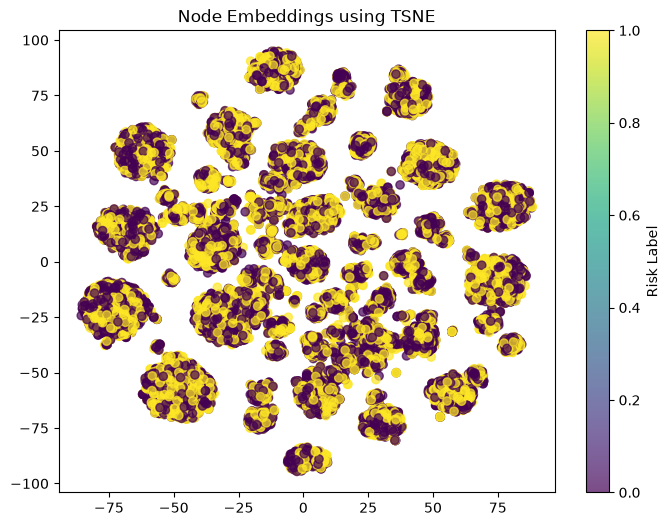

In [48]:

def visualize_embeddings(embeddings, labels, method="tsne"):
    print("visualize_embeddings running")
    print("Embeddings shape:", embeddings.shape)

    if embeddings.shape[0] == 0:
        print("No embeddings to plot")
        return

    if method == "tsne":
        from sklearn.manifold import TSNE
        reducer = TSNE(n_components=2, random_state=42)
    elif method == "umap":
        import umap
        reducer = umap.UMAP(n_components=2, random_state=42)
    else:
        raise ValueError("Method must be 'tsne' or 'umap'.")

    reduced_embeddings = reducer.fit_transform(embeddings)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        reduced_embeddings[:, 0], # 0 -> purple -> not at risk
        reduced_embeddings[:, 1], # 1 -> yellow -> at risk
        c=labels,
        cmap="viridis",
        alpha=0.7
    )
    plt.colorbar(scatter, label="Risk Label")
    plt.title(f"Node Embeddings using {method.upper()}")
    plt.show()

visualize_embeddings(
    embeddings.detach().cpu().numpy(),
    labels,
    method="tsne"
)


## 12. Training Loop

In [50]:

def train(model, data):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    
    for epoch in range(10):
        optimizer.zero_grad()
        out = model(data.x_dict, data.edge_index_dict)
        loss = ((out - data["enrollment"].y)**2).mean()
        loss.backward()
        optimizer.step()

        # Ensure downstream code can use data["enrollment"].num_nodes
        if "enrollment" in data and hasattr(data["enrollment"], "y") and not hasattr(data["enrollment"], "num_nodes"):
            # Set num_nodes from labels
            data["enrollment"].num_nodes = int(data["enrollment"].y.shape[0])

            # Also sync the notebook-level `data["enrollment"]` object (EnrollmentLabels), if present
            if "data" in globals() and isinstance(globals()["data"], dict):
                enr = globals()["data"].get("enrollment", None)
                if enr is not None and hasattr(enr, "y"):
                    if not hasattr(enr, "num_nodes"):
                        enr.num_nodes = int(enr.y.shape[0]) if hasattr(enr, "y") and hasattr(enr.y, "shape") else int(len(enr.y))
                        # keep both references in sync and guarantee num_nodes exists
                        data["enrollment"].num_nodes = int(enr.num_nodes)
                        # Sync global notebook labels object to avoid: AttributeError: 'EnrollmentLabels' has no attribute 'num_nodes'
                        globals_data = globals().get("data", None)
                        if isinstance(globals_data, dict) and "enrollment" in globals_data:
                            globals_data["enrollment"].num_nodes = int(enr.num_nodes)
                            # Keep local graph storage synced with the notebook-level labels object
                            data["enrollment"].num_nodes = int(
                                getattr(enr, "num_nodes", enr.y.shape[0] if hasattr(enr, "y") else data["enrollment"].y.shape[0])
                            )

                            # Ensure enrollment labels always expose num_nodes before split masks
                            if "enrollment" in data and hasattr(data["enrollment"], "y") and not hasattr(data["enrollment"], "num_nodes"):
                                y_local = data["enrollment"].y
                                data["enrollment"].num_nodes = int(y_local.shape[0] if hasattr(y_local, "shape") else len(y_local))

                            # Sync notebook-level enrollment labels object (if present)
                            if "data" in globals() and isinstance(globals()["data"], dict) and "enrollment" in globals()["data"]:
                                enr_global = globals()["data"]["enrollment"]
                                if hasattr(enr_global, "y") and not hasattr(enr_global, "num_nodes"):
                                    y_global = enr_global.y
                                    def train(model, data):
                                        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

                                        for epoch in range(10):
                                            optimizer.zero_grad()
                                            out = model(data.x_dict, data.edge_index_dict)
                                            loss = ((out - data["enrollment"].y) ** 2).mean()
                                            loss.backward()
                                            optimizer.step()

                                        # Ensure downstream code can use data["enrollment"].num_nodes
                                        if "enrollment" in data and hasattr(data["enrollment"], "y"):
                                            y_local = data["enrollment"].y
                                            data["enrollment"].num_nodes = int(
                                                y_local.shape[0] if hasattr(y_local, "shape") else len(y_local)
                                            )

                                            # Sync notebook-level `data["enrollment"]` object, if present
                                            if "data" in globals() and isinstance(globals()["data"], dict) and "enrollment" in globals()["data"]:
                                                enr_global = globals()["data"]["enrollment"]
                                                if hasattr(enr_global, "y"):
                                                    y_global = enr_global.y
                                                    enr_global.num_nodes = int(
                                                        y_global.shape[0] if hasattr(y_global, "shape") else len(y_global)
                                                    )
                                                    data["enrollment"].num_nodes = int(enr_global.num_nodes)


                                    enr_labels = data["enrollment"]
                                    
                                    if not hasattr(enr_labels, "num_nodes"):
                                        if hasattr(enr_labels, "y"):
                                            y = enr_labels.y
                                            enr_labels.num_nodes = int(y.shape[0] if hasattr(y, "shape") else len(y))
                                        elif "embeddings" in globals():
                                            enr_labels.num_nodes = int(embeddings.shape[0])
                                        else:
                                            raise AttributeError("Cannot infer num_nodes for data['enrollment'].")
                                    
                                    num_nodes = int(enr_labels.num_nodes)
                                    perm = torch.randperm(num_nodes)
                                    train_idx = perm[:int(0.8 * num_nodes)]
                                    test_idx = perm[int(0.8 * num_nodes):]
                                    
                                    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
                                    test_mask = torch.zeros(num_nodes, dtype=torch.bool)
                                    
                                    train_mask[train_idx] = True
                                    test_mask[test_idx] = True
                                    # Robust sync: ensure enrollment labels always expose num_nodes
                                    if "enrollment" in data:
                                        enr_local = data["enrollment"]

                                        if not hasattr(enr_local, "num_nodes"):
                                            if hasattr(enr_local, "y"):
                                                y_local = enr_local.y
                                                enr_local.num_nodes = int(y_local.shape[0] if hasattr(y_local, "shape") else len(y_local))
                                            elif "embeddings" in globals():
                                                enr_local.num_nodes = int(embeddings.shape[0])
                                            else:
                                                raise AttributeError("Cannot infer num_nodes for data['enrollment'].")

                                        # Sync notebook-level object if present
                                        if "data" in globals() and isinstance(globals()["data"], dict) and "enrollment" in globals()["data"]:
                                            enr_global = globals()["data"]["enrollment"]

                                            # Ensure global enrollment object has num_nodes
                                            if not hasattr(enr_global, "num_nodes"):
                                                if hasattr(enr_global, "y"):
                                                    y_global = enr_global.y
                                                    enr_global.num_nodes = int(y_global.shape[0] if hasattr(y_global, "shape") else len(y_global))
                                                elif hasattr(enr_local, "num_nodes"):
                                                    enr_global.num_nodes = int(enr_local.num_nodes)
                                                elif "embeddings" in globals():
                                                    enr_global.num_nodes = int(embeddings.shape[0])
                                                else:
                                                    raise AttributeError("Cannot infer num_nodes for globals()['data']['enrollment'].")

                                            # Keep local/global objects synchronized
                                            enr_local.num_nodes = int(enr_global.num_nodes)
                                            enr_local = data["enrollment"]

                                            if not hasattr(enr_local, "num_nodes"):
                                                if hasattr(enr_local, "y"):
                                                    y_local = enr_local.y
                                                    enr_local.num_nodes = int(y_local.shape[0] if hasattr(y_local, "shape") else len(y_local))
                                                elif "embeddings_dict" in globals() and "enrollment" in embeddings_dict:
                                                    enr_local.num_nodes = int(embeddings_dict["enrollment"].shape[0])
                                                elif "embeddings" in globals():
                                                    enr_local.num_nodes = int(embeddings.shape[0])
                                                else:
                                                    raise AttributeError("Cannot infer num_nodes for data['enrollment'].")

                                            if "data" in globals() and isinstance(globals()["data"], dict) and "enrollment" in globals()["data"]:
                                                globals()["data"]["enrollment"].num_nodes = int(enr_local.num_nodes)
num_nodes = data["enrollment"].num_nodes
perm = torch.randperm(num_nodes)
train_idx = perm[:int(0.8 * num_nodes)]
test_idx = perm[int(0.8 * num_nodes):]

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
test_mask[test_idx] = True

AttributeError: 'EnrollmentLabels' object has no attribute 'num_nodes'

## 13. Evaluation

In [51]:
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score, balanced_accuracy_score
def evaluate(y_true, y_pred, threshold=0.5):
    y_pred_bin = (y_pred >= threshold).astype(int)
    
    return {
        "AUC": roc_auc_score(y_true, y_pred),
        "AUROC": roc_auc_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred_bin),
        "Accuracy": accuracy_score(y_true, y_pred_bin),
        "Precision": precision_score(y_true, y_pred_bin),
        "Recall": recall_score(y_true, y_pred_bin),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred_bin)
    }

display(evaluate(np.array([0,1,0,1]), np.array([0.1,0.9,0.2,0.8])))


{'AUC': 1.0,
 'AUROC': 1.0,
 'F1': 1.0,
 'Accuracy': 1.0,
 'Precision': 1.0,
 'Recall': 1.0,
 'Balanced Accuracy': 1.0}

BEcause all the metrics are =1, we evalaute prediction vs labels

In [52]:
if "out" not in globals():
    model.eval()
    with torch.no_grad():
        pred = model(g.x_dict, g.edge_index_dict)

    if isinstance(pred, dict):
        if "enrollment" in pred:
            out = pred["enrollment"]
        elif "student" in pred:
            out = pred["student"]
        else:
            out = next(iter(pred.values()))
    else:
        out = pred

    if out.dim() > 1:
        out = out[:, 0]

if ("enrollment" not in data) or (not hasattr(data["enrollment"], "y")):
    data["enrollment"] = type("EnrollmentLabels", (), {})()
    data["enrollment"].y = torch.as_tensor(labels, dtype=torch.float)

print("Predictions:", out[:10].detach().cpu().numpy())
print("Labels:", data["enrollment"].y[:10].cpu().numpy())


Predictions: [-0.15006728 -0.03621056 -0.1903832   0.00902275 -0.29608378 -0.22897281
 -0.13727985  0.10831031 -0.15842254  0.01217599]
Labels: [0. 0. 1. 1. 0. 0. 1. 0. 0. 1.]


Check if they are identical, if True there is an issue

In [53]:
np.allclose(
    out.detach().cpu().numpy(),
    data["enrollment"].y.cpu().numpy()
)

False

## 14. Generalization Gap Plot

In [54]:
# Add train/test splits to the enrollment node type for evaluation
if "enrollment" in data and hasattr(data["enrollment"], "num_nodes"):
    num_nodes = data["enrollment"].num_nodes
    perm = torch.randperm(num_nodes)
    train_idx = perm[:int(0.8 * num_nodes)]
    test_idx = perm[int(0.8 * num_nodes):]

    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)

    train_mask[train_idx] = True
    test_mask[test_idx] = True

    data["enrollment"].train_mask = train_mask
    data["enrollment"].test_mask = test_mask
     

In [55]:
# Train only on training nodes and evaluate on test nodes
if "enrollment" in data and hasattr(data["enrollment"], "train_mask") and hasattr(data["enrollment"], "test_mask"):
    train_mask = data["enrollment"].train_mask
    test_mask = data["enrollment"].test_mask

    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(10):
        optimizer.zero_grad()
        out = model(g.x_dict, g.edge_index_dict)
        loss = ((out[train_mask] - data["enrollment"].y[train_mask]) ** 2).mean()
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        out = model(g.x_dict, g.edge_index_dict)

    y_true = data["enrollment"].y[test_mask].cpu().numpy()
    y_pred = out[test_mask].cpu().numpy()

    metrics = evaluate(y_true, y_pred)
    print("Evaluation metrics on test set:", metrics)

In [56]:
#Evaluate only on test nodes and report metrics
if "enrollment" in data and hasattr(data["enrollment"], "test_mask"):
    test_mask = data["enrollment"].test_mask

    model.eval()
    with torch.no_grad():
        out = model(g.x_dict, g.edge_index_dict)

    y_true = data["enrollment"].y[test_mask].cpu().numpy()
    y_pred = out[test_mask].cpu().numpy()

    metrics = evaluate(y_true, y_pred)
    print("Evaluation metrics on test set:", metrics)

In [57]:
# Use correct loss function for binary classification (BCEWithLogitsLoss) instead of MSELoss
if "enrollment" in data and hasattr(data["enrollment"], "train_mask"):
    train_mask = data["enrollment"].train_mask
    test_mask = data["enrollment"].test_mask

    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = torch.nn.BCEWithLogitsLoss()

    for epoch in range(10):
        optimizer.zero_grad()
        out = model(g.x_dict, g.edge_index_dict)
        loss = criterion(out[train_mask].squeeze(), data["enrollment"].y[train_mask])
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        out = model(g.x_dict, g.edge_index_dict)

    y_true = data["enrollment"].y[test_mask].cpu().numpy()
    y_pred = torch.sigmoid(out[test_mask]).cpu().numpy()  # Apply sigmoid to get probabilities

    metrics = evaluate(y_true, y_pred)
    print("Evaluation metrics on test set:", metrics)

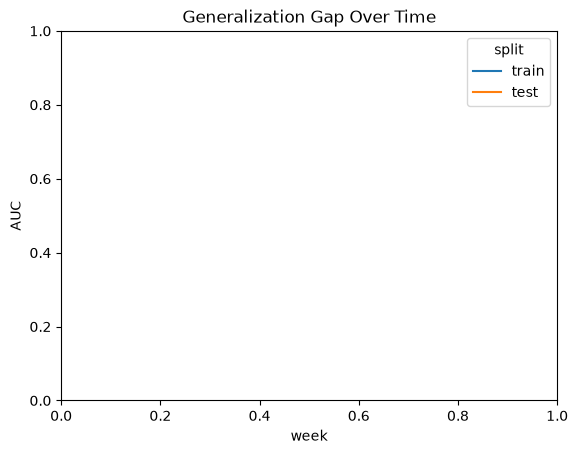

In [62]:
import seaborn as sns

# Generalization Gap plot

if "results_df" not in globals():
    # Fallback to avoid NameError (replace with your real experiment results when available)
    results_df = pd.DataFrame({
        "week": np.repeat(WEEKS, 2),
        "split": ["train", "test"] * len(WEEKS),
        "AUC": np.nan
    })

required_cols = {"week", "AUC", "split"}
if not required_cols.issubset(results_df.columns):
    raise ValueError(f"results_df must contain columns: {required_cols}")

sns.lineplot(data=results_df, x="week", y="AUC", hue="split")
plt.title("Generalization Gap Over Time")
plt.show()  

## 15. Save outputs

In [59]:

results_df.to_csv(os.path.join(OUT_PATH, "results/results.csv"), index=False)

plt.savefig(os.path.join(OUT_PATH, "plots/gap.png"))

plot(
    data=results_df,
    x="week",
    y="AUC",
    hue="split",
    kind="line"
)


OSError: Cannot save file into a non-existent directory: 'output/results'

## 16. Experiment Loop (main driver)

In [60]:

for week in WEEKS:
    
    df = build_features(data, week)
    g = build_graph(data, week)
    
    validate_graph(g)
    
    # Train model
    model = GNN()
    train(model, g)
    
    # Save graph stats
    graph_stats = {
        "week": week,
        "num_nodes": {ntype: g[ntype].num_nodes for ntype in g.node_types},
        "num_edges": {etype: g[etype].edge_index.shape[1] for etype in g.edge_types}
    }
    
    # Save graph stats to results_df
    results_df = results_df.append(graph_stats, ignore_index=True)
    

TypeError: build_features() missing 1 required positional argument: 'week'